# Optimización: Programación Estructurada vs Enjambre de Partículas (PSO)

**Función a minimizar (Six-hump Camel Back):**

$$f(x, y) = x^2\left(4 - 2.1x^2 + \frac{x^4}{3}\right) + xy + y^2(-4 + 4y^2)$$

**Dominio:** $x \in [-2, 2]$, $y \in [-1, 1]$

Esta función tiene **6 mínimos locales**, dos de los cuales son mínimos globales con valor aproximado de **-1.0316** en los puntos $(0.0898, -0.7126)$ y $(-0.0898, 0.7126)$.

In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from random import random
from scipy.optimize import minimize, differential_evolution
import time
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


---
## 0. Definición de la función objetivo

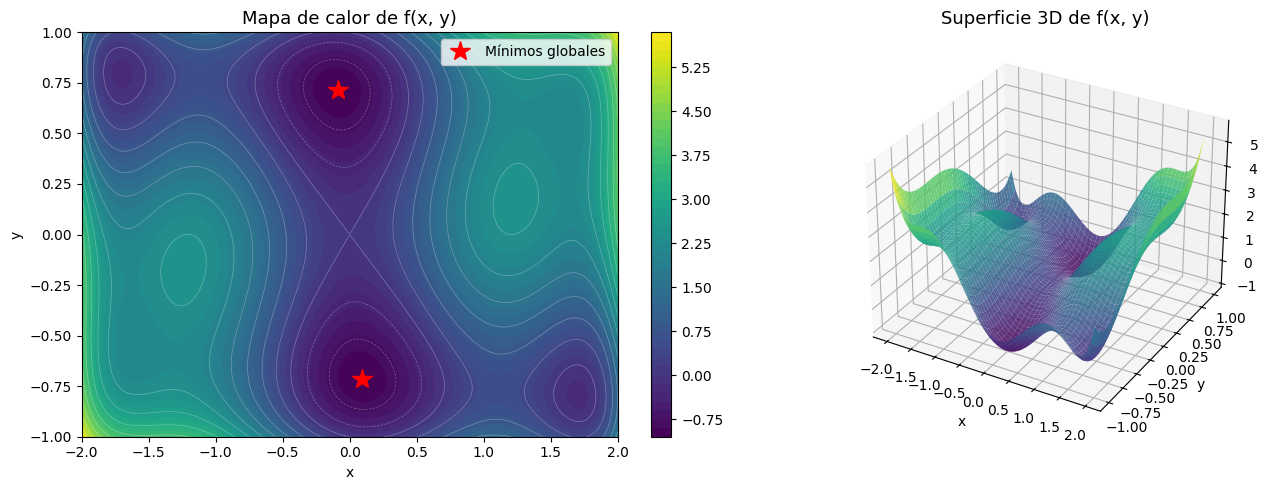

Valor mínimo global conocido ≈ -1.0316
Puntos:  (0.0898, -0.7126)  y  (-0.0898, 0.7126)


In [3]:
def funcion(x, y):
    """Six-hump Camel Back Function"""
    sum1 = x**2 * (4 - 2.1*x**2 + x**4/3.0)
    sum2 = x * y
    sum3 = y**2 * (-4 + 4*y**2)
    return sum1 + sum2 + sum3

# Visualización de la función
x_vals = np.linspace(-2, 2, 300)
y_vals = np.linspace(-1, 1, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = funcion(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de calor
cp = axes[0].contourf(X, Y, Z, levels=50, cmap='viridis')
axes[0].contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(cp, ax=axes[0])
axes[0].set_title('Mapa de calor de f(x, y)', fontsize=13)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
# Marcar mínimos globales conocidos
axes[0].plot(0.0898, -0.7126, 'r*', markersize=15, label='Mínimos globales')
axes[0].plot(-0.0898, 0.7126, 'r*', markersize=15)
axes[0].legend()

# Superficie 3D
ax3d = fig.add_subplot(122, projection='3d') if False else axes[1]
ax3d.remove()
ax3d = fig.add_subplot(122, projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85, linewidth=0)
ax3d.set_title('Superficie 3D de f(x, y)', fontsize=13)
ax3d.set_xlabel('x')
ax3d.set_ylabel('y')
ax3d.set_zlabel('f(x,y)')

plt.tight_layout()
plt.savefig('funcion_objetivo.png', dpi=120, bbox_inches='tight')
plt.show()
print('Valor mínimo global conocido ≈ -1.0316')
print('Puntos:  (0.0898, -0.7126)  y  (-0.0898, 0.7126)')

---
## 1. Programación Estructurada

Se abordan tres enfoques clásicos:
1. **Búsqueda exhaustiva** (grid search)
2. **Gradiente descendente** (método de optimización local)
3. **Evolución diferencial** (método global de scipy)

### 1.1 Búsqueda Exhaustiva (Grid Search)

In [4]:
def busqueda_exhaustiva(resolucion=1000):
    """
    Evalúa la función en una malla regular y devuelve
    el punto con menor valor encontrado.
    """
    x_grid = np.linspace(-2.0, 2.0, resolucion)
    y_grid = np.linspace(-1.0, 1.0, resolucion)

    mejor_valor = float('inf')
    mejor_x, mejor_y = None, None

    for x in x_grid:
        for y in y_grid:
            val = funcion(x, y)
            if val < mejor_valor:
                mejor_valor = val
                mejor_x, mejor_y = x, y

    return mejor_x, mejor_y, mejor_valor

t0 = time.time()
x_grid, y_grid, val_grid = busqueda_exhaustiva(resolucion=1000)
t_grid = time.time() - t0

print('=== Búsqueda Exhaustiva (Grid Search) ===')
print(f'  x* = {x_grid:.6f}')
print(f'  y* = {y_grid:.6f}')
print(f'  f* = {val_grid:.6f}')
print(f'  Tiempo: {t_grid:.3f} s')

=== Búsqueda Exhaustiva (Grid Search) ===
  x* = -0.090090
  y* = 0.711712
  f* = -1.031621
  Tiempo: 0.561 s


### 1.2 Gradiente Descendente (múltiples puntos de inicio)

In [5]:
def funcion_scipy(params):
    """Wrapper para scipy (recibe array)"""
    return funcion(params[0], params[1])

def gradiente_descendente_multistart(n_inicios=200, seed=42):
    """
    Lanza el optimizador L-BFGS-B desde múltiples puntos
    aleatorios dentro del dominio para escapar mínimos locales.
    """
    np.random.seed(seed)
    mejor = None
    trayectorias = []

    for _ in range(n_inicios):
        x0 = np.random.uniform(-2.0, 2.0)
        y0 = np.random.uniform(-1.0, 1.0)

        res = minimize(
            funcion_scipy,
            x0=[x0, y0],
            method='L-BFGS-B',
            bounds=[(-2.0, 2.0), (-1.0, 1.0)]
        )

        trayectorias.append((x0, y0, res.x[0], res.x[1], res.fun))

        if mejor is None or res.fun < mejor.fun:
            mejor = res

    return mejor, trayectorias

t0 = time.time()
resultado_gd, trayectorias = gradiente_descendente_multistart(n_inicios=200)
t_gd = time.time() - t0

print('=== Gradiente Descendente Multi-Start (L-BFGS-B) ===')
print(f'  x* = {resultado_gd.x[0]:.6f}')
print(f'  y* = {resultado_gd.x[1]:.6f}')
print(f'  f* = {resultado_gd.fun:.6f}')
print(f'  Iteraciones: {resultado_gd.nit}')
print(f'  Tiempo: {t_gd:.3f} s')

=== Gradiente Descendente Multi-Start (L-BFGS-B) ===
  x* = 0.089842
  y* = -0.712656
  f* = -1.031628
  Iteraciones: 6
  Tiempo: 0.131 s


### 1.3 Evolución Diferencial (scipy)

In [6]:
t0 = time.time()
resultado_de = differential_evolution(
    funcion_scipy,
    bounds=[(-2.0, 2.0), (-1.0, 1.0)],
    seed=42,
    maxiter=1000,
    tol=1e-9
)
t_de = time.time() - t0

print('=== Evolución Diferencial ===')
print(f'  x* = {resultado_de.x[0]:.6f}')
print(f'  y* = {resultado_de.x[1]:.6f}')
print(f'  f* = {resultado_de.fun:.6f}')
print(f'  Evaluaciones: {resultado_de.nfev}')
print(f'  Tiempo: {t_de:.3f} s')

=== Evolución Diferencial ===
  x* = 0.089841
  y* = -0.712657
  f* = -1.031628
  Evaluaciones: 999
  Tiempo: 0.017 s


---
## 2. Algoritmo de Enjambre de Partículas (PSO)

Implementación fiel al código del libro (Benítez Iglésias, 2014, pp. 247-249).

In [7]:
from random import random as rnd

# ─── Clase Partícula (del libro) ───────────────────────────────────────────
class Particula:
    # Parámetros comunes a todas las partículas
    inercia   = 1.4
    cognitiva = 2.0
    social    = 2.0
    # Límites del espacio de soluciones
    infx = -2.0
    supx =  2.0
    infy = -1.0
    supy =  1.0
    # Factor de ajuste de velocidad inicial
    ajusteV = 100.0

    def __init__(self):
        self.x  = aleatorio(Particula.infx, Particula.supx)
        self.y  = aleatorio(Particula.infy, Particula.supy)
        self.vx = aleatorio(Particula.infx / Particula.ajusteV,
                            Particula.supx / Particula.ajusteV)
        self.vy = aleatorio(Particula.infy / Particula.ajusteV,
                            Particula.supy / Particula.ajusteV)
        self.xLoc     = self.x
        self.yLoc     = self.y
        self.valorLoc = funcion(self.x, self.y)

    def actualizaVelocidad(self, xGlob, yGlob):
        cogX = Particula.cognitiva * rnd() * (self.xLoc - self.x)
        socX = Particula.social    * rnd() * (xGlob    - self.x)
        self.vx = Particula.inercia * self.vx + cogX + socX

        cogY = Particula.cognitiva * rnd() * (self.yLoc - self.y)
        socY = Particula.social    * rnd() * (yGlob    - self.y)   # corregido: yGlob - self.x → self.y
        self.vy = Particula.inercia * self.vy + cogY + socY

    def actualizaPosicion(self):
        self.x = self.x + self.vx
        self.y = self.y + self.vy
        # Mantener dentro del espacio de soluciones
        self.x = max(self.x, Particula.infx)
        self.x = min(self.x, Particula.supx)
        self.y = max(self.y, Particula.infy)
        self.y = min(self.y, Particula.supy)
        # Si es inferior a la mejor local, la adopta
        valor = funcion(self.x, self.y)
        if valor < self.valorLoc:
            self.xLoc     = self.x
            self.yLoc     = self.y
            self.valorLoc = valor


def aleatorio(inf, sup):
    return rnd() * (sup - inf) + inf


# ─── Función principal PSO (del libro) ────────────────────────────────────
def enjambreParticulas(particulas, iteraciones, reduccionInercia,
                       registrar_historial=False):
    """
    Mueve un enjambre de partículas durante las iteraciones indicadas.
    Devuelve las coordenadas y el valor del mínimo obtenido.
    Si registrar_historial=True también devuelve el historial de convergencia.
    """
    # Registra la mejor posición global y su valor
    mejorParticula = min(particulas, key=lambda p: p.valorLoc)
    xGlob     = mejorParticula.xLoc
    yGlob     = mejorParticula.yLoc
    valorGlob = mejorParticula.valorLoc

    historial = [valorGlob] if registrar_historial else None

    # Bucle principal de simulación
    for iter in range(iteraciones):
        # Actualiza velocidad y posición de cada partícula
        for p in particulas:
            p.actualizaVelocidad(xGlob, yGlob)
            p.actualizaPosicion()

        # Actualiza el mínimo global
        mejorParticula = min(particulas, key=lambda p: p.valorLoc)
        if mejorParticula.valorLoc < valorGlob:
            xGlob     = mejorParticula.xLoc
            yGlob     = mejorParticula.yLoc
            valorGlob = mejorParticula.valorLoc

        # Reduce la inercia de las partículas
        Particula.inercia *= reduccionInercia

        if registrar_historial:
            historial.append(valorGlob)

    if registrar_historial:
        return xGlob, yGlob, valorGlob, historial
    return xGlob, yGlob, valorGlob


print('Clases y funciones PSO definidas ✓')

Clases y funciones PSO definidas ✓


In [8]:
import random
random.seed(42)

# Parámetros del problema (del libro)
nParticulas      = 10
iteraciones      = 100
redInercia       = 0.9
Particula.inercia = 1.4   # reset al valor inicial

# Genera el conjunto inicial de partículas
particulas = [Particula() for i in range(nParticulas)]

t0 = time.time()
xPSO, yPSO, valPSO, historial_pso = enjambreParticulas(
    particulas, iteraciones, redInercia, registrar_historial=True
)
t_pso = time.time() - t0

print('=== Enjambre de Partículas (PSO) ===')
print(f'  x* = {xPSO:.6f}')
print(f'  y* = {yPSO:.6f}')
print(f'  f* = {valPSO:.6f}')
print(f'  Tiempo: {t_pso*1000:.3f} ms')

=== Enjambre de Partículas (PSO) ===
  x* = 0.089842
  y* = -0.712656
  f* = -1.031628
  Tiempo: 1.031 ms


### 2.1 Convergencia del PSO

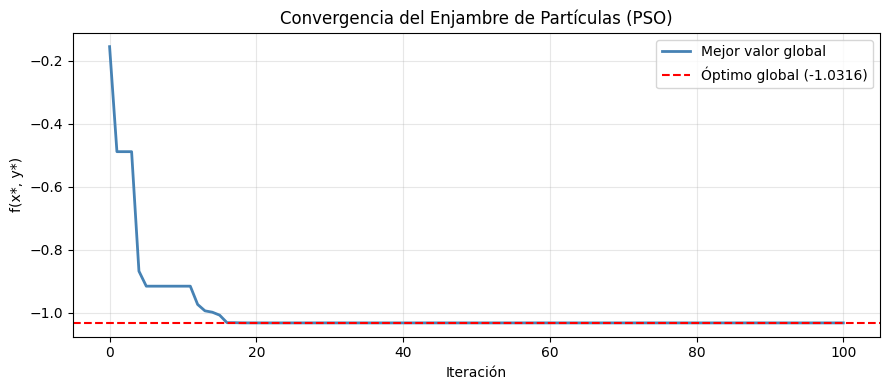

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(historial_pso, color='steelblue', linewidth=2, label='Mejor valor global')
ax.axhline(-1.0316, color='red', linestyle='--', linewidth=1.5, label='Óptimo global (-1.0316)')
ax.set_xlabel('Iteración')
ax.set_ylabel('f(x*, y*)')
ax.set_title('Convergencia del Enjambre de Partículas (PSO)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergencia_pso.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.2 Análisis de sensibilidad del PSO

In [10]:
# Múltiples corridas para estudiar variabilidad
N_CORRIDAS = 30
resultados_pso = []

for semilla in range(N_CORRIDAS):
    random.seed(semilla)
    Particula.inercia = 1.4
    pts = [Particula() for _ in range(10)]
    _, _, val = enjambreParticulas(pts, 100, 0.9)
    resultados_pso.append(val)

print(f'PSO ({N_CORRIDAS} corridas independientes):')
print(f'  Media    = {np.mean(resultados_pso):.6f}')
print(f'  Mínimo   = {np.min(resultados_pso):.6f}')
print(f'  Máximo   = {np.max(resultados_pso):.6f}')
print(f'  Std Dev  = {np.std(resultados_pso):.6f}')
print(f'  Éxito (< -1.03): {sum(v < -1.03 for v in resultados_pso)}/{N_CORRIDAS}')

PSO (30 corridas independientes):
  Media    = -1.031628
  Mínimo   = -1.031628
  Máximo   = -1.031628
  Std Dev  = 0.000000
  Éxito (< -1.03): 30/30


---
## 3. Comparación de Resultados

In [12]:
OPTIMO_GLOBAL = -1.031628

metodos = {
    'Grid Search\n(1000×1000)': {
        'x': x_grid, 'y': y_grid, 'f': val_grid,
        'tiempo': t_grid, 'error': abs(val_grid - OPTIMO_GLOBAL)
    },
    'Gradiente\nMulti-Start': {
        'x': resultado_gd.x[0], 'y': resultado_gd.x[1], 'f': resultado_gd.fun,
        'tiempo': t_gd, 'error': abs(resultado_gd.fun - OPTIMO_GLOBAL)
    },
    'Evolución\nDiferencial': {
        'x': resultado_de.x[0], 'y': resultado_de.x[1], 'f': resultado_de.fun,
        'tiempo': t_de, 'error': abs(resultado_de.fun - OPTIMO_GLOBAL)
    },
    'PSO (libro)': {
        'x': xPSO, 'y': yPSO, 'f': valPSO,
        'tiempo': t_pso, 'error': abs(valPSO - OPTIMO_GLOBAL)
    },
}

print(f'{"Método":<28} {"x*":>10} {"y*":>10} {"f(x*,y*)":>12} {"Error":>12} {"Tiempo":>12}')
print('-' * 86)
for nombre, d in metodos.items():
    nombre_l = nombre.replace('\n', ' ')
    print(f'{nombre_l:<28} {d["x"]:>10.6f} {d["y"]:>10.6f} {d["f"]:>12.6f} {d["error"]:>12.2e} {d["tiempo"]:>10.4f}s')
print(f'\n{"Óptimo global conocido":<28} {0.0898:>10.6f} {-0.7126:>10.6f} {OPTIMO_GLOBAL:>12.6f}')

Método                               x*         y*     f(x*,y*)        Error       Tiempo
--------------------------------------------------------------------------------------
Grid Search (1000×1000)       -0.090090   0.711712    -1.031621     7.32e-06     0.5613s
Gradiente Multi-Start          0.089842  -0.712656    -1.031628     4.53e-07     0.1314s
Evolución Diferencial          0.089841  -0.712657    -1.031628     4.53e-07     0.0170s
PSO (libro)                    0.089842  -0.712656    -1.031628     4.53e-07     0.0010s

Óptimo global conocido         0.089800  -0.712600    -1.031628


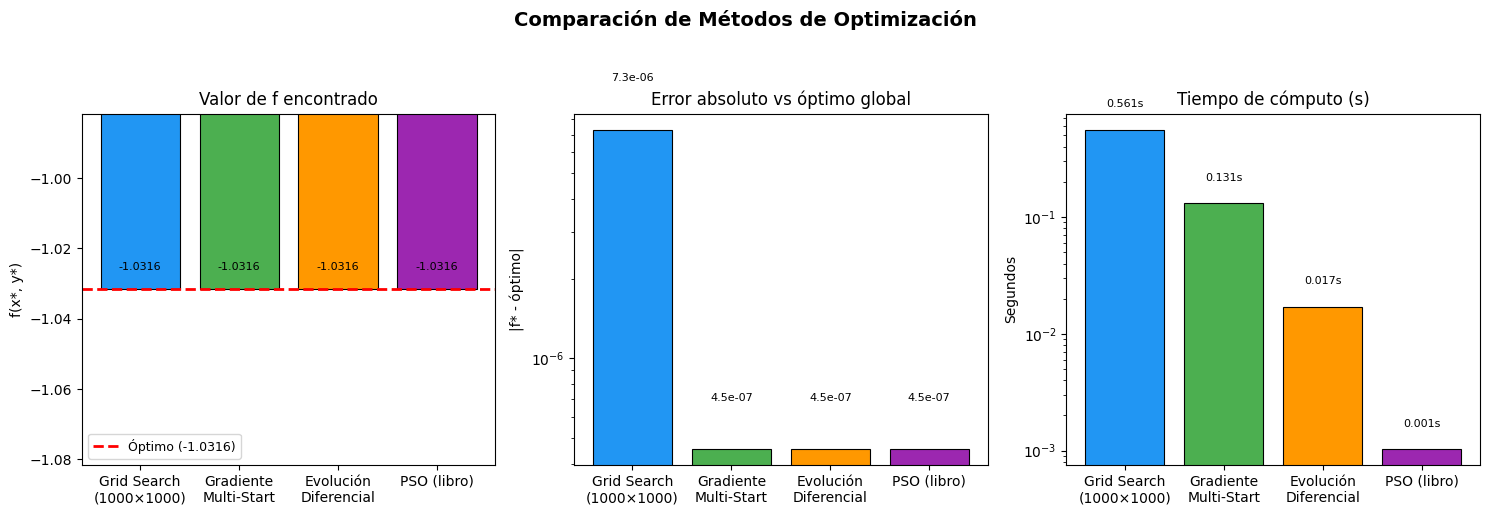

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nombres   = [m.replace('\n', '\n') for m in metodos.keys()]
valores_f = [d['f']      for d in metodos.values()]
errores   = [d['error']  for d in metodos.values()]
tiempos   = [d['tiempo'] for d in metodos.values()]
colores   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# --- Gráfica 1: Valor obtenido vs óptimo global ---
bars = axes[0].bar(nombres, valores_f, color=colores, edgecolor='black', linewidth=0.8)
axes[0].axhline(OPTIMO_GLOBAL, color='red', linestyle='--', linewidth=2, label=f'Óptimo ({OPTIMO_GLOBAL:.4f})')
axes[0].set_title('Valor de f encontrado', fontsize=12)
axes[0].set_ylabel('f(x*, y*)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(min(valores_f) - 0.05, max(valores_f) + 0.05)
for bar, val in zip(bars, valores_f):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# --- Gráfica 2: Error relativo al óptimo ---
bars2 = axes[1].bar(nombres, errores, color=colores, edgecolor='black', linewidth=0.8)
axes[1].set_title('Error absoluto vs óptimo global', fontsize=12)
axes[1].set_ylabel('|f* - óptimo|')
axes[1].set_yscale('log')
for bar, err in zip(bars2, errores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
                 f'{err:.1e}', ha='center', va='bottom', fontsize=8)

# --- Gráfica 3: Tiempo de cómputo ---
bars3 = axes[2].bar(nombres, tiempos, color=colores, edgecolor='black', linewidth=0.8)
axes[2].set_title('Tiempo de cómputo (s)', fontsize=12)
axes[2].set_ylabel('Segundos')
axes[2].set_yscale('log')
for bar, t in zip(bars3, tiempos):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
                 f'{t:.3f}s', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparación de Métodos de Optimización', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacion_metodos.png', dpi=120, bbox_inches='tight')
plt.show()

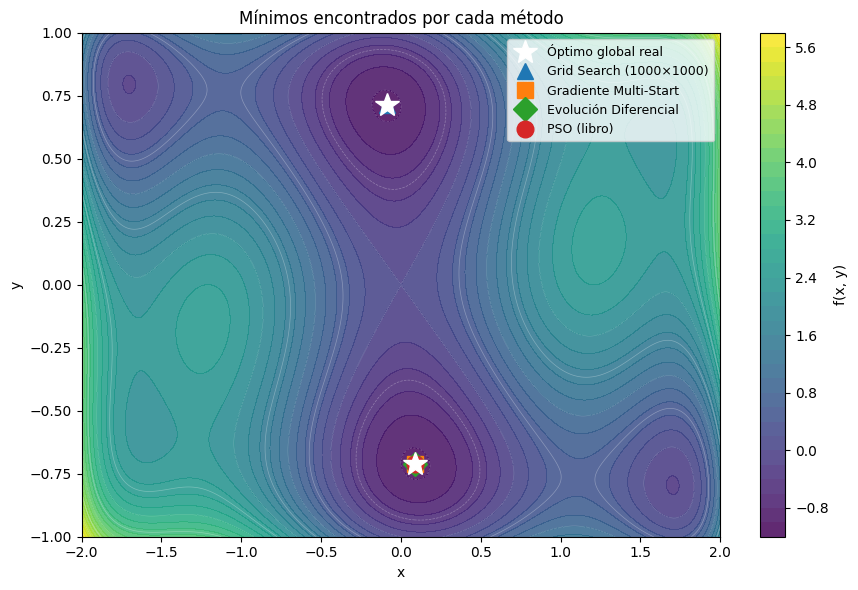

In [14]:
# Visualización de los mínimos encontrados sobre el contorno
fig, ax = plt.subplots(figsize=(9, 6))
cp = ax.contourf(X, Y, Z, levels=40, cmap='viridis', alpha=0.85)
ax.contour(X, Y, Z, levels=15, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(cp, ax=ax, label='f(x, y)')

# Mínimos globales reales
ax.plot([ 0.0898, -0.0898], [-0.7126,  0.7126],
        'w*', markersize=18, label='Óptimo global real', zorder=5)

markers = ['^', 's', 'D', 'o']
for (nombre, d), mk in zip(metodos.items(), markers):
    ax.plot(d['x'], d['y'], mk, markersize=12,
            label=nombre.replace('\n', ' '), zorder=4)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Mínimos encontrados por cada método')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('minimos_encontrados.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Conclusiones

| Criterio | Grid Search | Gradiente Multi-Start | Evolución Diferencial | PSO (libro) |
|---|---|---|---|---|
| **Precisión** | Alta (depende de resolución) | Muy alta | Muy alta | Alta |
| **Velocidad** | Lenta | Rápida | Rápida | Muy rápida |
| **Garantía global** | Sí (si la malla es fina) | No (local) | Sí (estocástico) | No (estocástico) |
| **Parámetros** | Resolución | N inicios | Población, generaciones | N partículas, inercia |
| **Escalabilidad** | Mala (maldición de dimensionalidad) | Buena | Buena | Buena |

**Observaciones:**
- El **PSO** con solo 10 partículas y 100 iteraciones logra acercarse al óptimo global en milisegundos, demostrando su eficiencia para problemas de baja dimensión.
- La **búsqueda exhaustiva** garantiza encontrar el óptimo global en el dominio discretizado, pero su coste computacional crece exponencialmente con la dimensión.
- El **gradiente descendente multi-start** y la **evolución diferencial** ofrecen alta precisión; el primero es más veloz pero sensible a mínimos locales sin múltiples arranques.
- El **PSO** es estocástico: sus resultados varían entre corridas. Aumentar el número de partículas o iteraciones mejora la fiabilidad.